In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv("data/mnist_train.csv", header=None)
data = np.array(data) # matrix of 60000 (samples) x 785 (features + 1 label) entries
m, n = data.shape # m = 60000, n = 785
np.random.shuffle(data)

In [3]:
data_dev = data[0:1000].T # we get a matrix of 785 rows and 1000 columns where the first row has labels, all other row has pixel values and each column is one sample
Y_dev = data_dev[0] # target values, first row
X_dev = data_dev[1:n] # all rows except the first one
X_dev = X_dev/255

data_train = data[1000:m].T # matrix of 785 rows and 59000 columns
Y_train = data_train[0] # vector of 59000 values
X_train = data_train[1:n] # matrix of 785 rows and 59000 columns
X_train = X_train/255

In [4]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(z):
    return np.maximum(0, z)

def deriv_ReLU(z):
    return z > 0

def softmax(z):
    prob = np.exp(z)/sum(np.exp(z))
    return prob

def forward_prop(W1, b1, W2, b2, X):
    z1 = W1.dot(X) + b1
    A1 = ReLU(z1)
    z2 = W2.dot(A1) + b2
    A2= softmax(z2)
    return z1, A1, z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max()+1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def back_prop(z1, A1, z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dz2 = A2 - one_hot_Y
    dW2 = 1/ m * dz2.dot(A1.T)
    db2 = 1/ m*np.sum(dz2)
    dz1 = W2.T.dot(dz2)*deriv_ReLU(z1)
    dW1 = 1/ m * dz1.dot(X.T)
    db1 = 1/ m*np.sum(dz1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha*dW1
    b1 = b1 - alpha*db1
    W2 = W2 - alpha*dW2
    b2 = b2 - alpha*db2
    return W1, b1, W2, b2

In [5]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        z1, A1, z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(z1, A1, z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        # print("Param W1:" , np.linalg.norm(W1))
        # print("Param W1:" , np.linalg.norm(W2))
        if i % 100 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print("Accuracy: ", get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [6]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 10000, 0.01)

Iteration:  0
[5 4 4 ... 5 4 5] [9 4 3 ... 1 6 1]
Accuracy:  0.10011864406779661
Iteration:  100
[8 2 4 ... 2 2 6] [9 4 3 ... 1 6 1]
Accuracy:  0.18601694915254238
Iteration:  200
[8 2 3 ... 2 2 5] [9 4 3 ... 1 6 1]
Accuracy:  0.24557627118644068
Iteration:  300
[8 2 3 ... 2 2 5] [9 4 3 ... 1 6 1]
Accuracy:  0.30322033898305084
Iteration:  400
[7 2 3 ... 2 3 5] [9 4 3 ... 1 6 1]
Accuracy:  0.3411016949152542
Iteration:  500
[7 2 3 ... 2 3 5] [9 4 3 ... 1 6 1]
Accuracy:  0.37286440677966104
Iteration:  600
[7 9 3 ... 2 3 5] [9 4 3 ... 1 6 1]
Accuracy:  0.40708474576271186
Iteration:  700
[7 9 6 ... 2 6 5] [9 4 3 ... 1 6 1]
Accuracy:  0.4640508474576271
Iteration:  800
[7 9 6 ... 1 6 5] [9 4 3 ... 1 6 1]
Accuracy:  0.5177457627118645
Iteration:  900
[7 9 6 ... 1 6 5] [9 4 3 ... 1 6 1]
Accuracy:  0.5590338983050848
Iteration:  1000
[7 9 6 ... 1 6 5] [9 4 3 ... 1 6 1]
Accuracy:  0.5944915254237289
Iteration:  1100
[7 9 6 ... 1 6 5] [9 4 3 ... 1 6 1]
Accuracy:  0.6263728813559322
Iteration:

In [7]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    predictions = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Predictions: ", predictions)
    print("Label: ", label)

    current_image = current_image.reshape((28,28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Predictions:  [1]
Label:  1


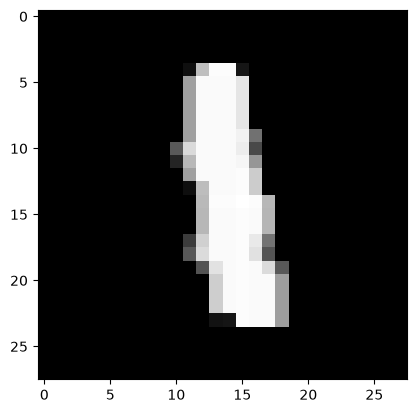

In [8]:
test_prediction(7382, W1, b1, W2, b2)

Predictions:  [3]
Label:  3


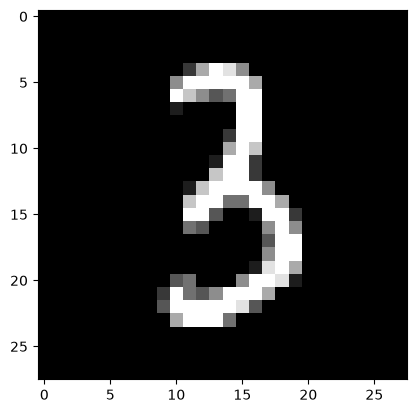

In [9]:
test_prediction(4829, W1, b1, W2, b2)


Predictions:  [4]
Label:  4


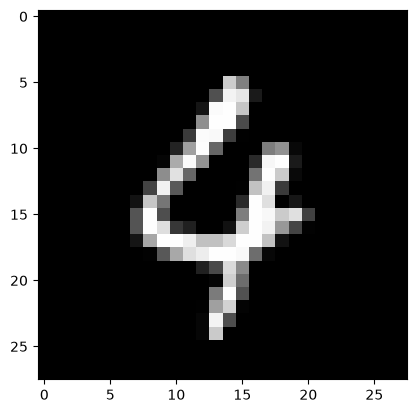

In [10]:
test_prediction(20, W1, b1, W2, b2)


Predictions:  [1]
Label:  1


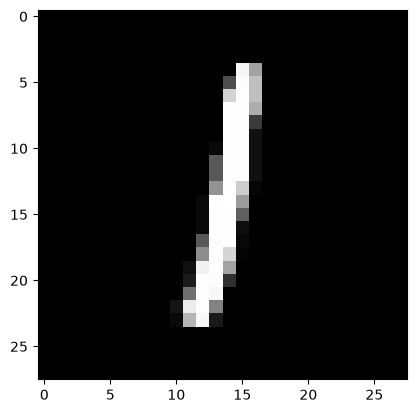

In [11]:
test_prediction(378, W1, b1, W2, b2)

In [12]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
print("Model performance on test set: ", get_accuracy(dev_predictions, Y_dev)*100)

[1 9 5 0 3 7 1 8 8 0 7 1 6 4 8 2 6 4 7 3 7 5 9 3 1 7 2 0 4 4 8 4 4 1 2 7 1
 9 3 1 2 5 4 4 2 9 3 2 0 1 5 0 9 1 2 1 7 4 6 2 5 3 2 8 0 1 4 6 4 1 2 8 1 6
 7 7 6 2 6 9 4 3 8 1 9 5 0 5 9 0 4 3 7 9 8 4 9 4 0 0 6 4 0 7 5 7 0 1 8 0 2
 6 1 5 0 7 6 8 9 5 8 7 5 5 4 0 5 8 6 5 0 1 9 8 7 2 1 6 0 2 7 5 4 9 8 6 5 7
 8 1 0 2 9 4 4 4 9 1 8 6 7 1 6 5 2 1 1 3 6 7 1 6 1 3 2 4 9 2 1 7 6 9 3 8 9
 1 0 1 2 2 1 1 2 0 7 3 6 5 3 3 5 6 1 7 8 2 9 0 6 1 4 5 3 0 1 2 3 3 0 9 4 4
 1 6 8 3 4 7 9 5 2 1 7 7 9 3 2 8 9 0 1 8 2 0 3 5 1 8 1 2 8 8 0 7 3 7 1 1 6
 7 4 4 5 6 5 8 0 6 9 7 7 3 6 0 7 2 4 8 8 6 0 3 3 1 9 2 1 7 8 2 0 8 7 8 0 1
 6 5 0 7 4 9 8 2 4 0 2 8 9 1 7 6 6 4 6 6 3 9 7 4 6 1 4 7 9 1 9 6 0 5 2 7 5
 0 7 8 1 8 2 3 6 5 3 7 1 4 8 9 0 2 3 2 1 7 2 6 1 2 7 0 1 6 6 3 6 8 0 2 9 7
 0 8 8 2 0 4 2 5 7 0 5 3 9 1 2 0 6 7 3 5 3 4 9 8 0 6 8 1 6 4 1 8 8 8 1 6 5
 5 2 9 0 1 0 0 9 8 5 2 6 5 7 0 6 8 6 3 8 4 3 7 2 8 7 3 8 0 1 6 6 8 2 0 5 2
 6 8 2 3 7 8 5 6 9 7 0 2 1 0 4 2 3 3 0 2 7 1 1 7 0 4 6 4 9 3 2 1 9 4 3 9 3
 9 3 8 2 3 8 1 2 2 2 7 7 